# Molecular Dynamics Histone Deacetylase 8

In this notebook a molecular dynamics approach was used to get a better insight of functional and structural changes of SMC3 caused by mutations. Specifically there is a focus Cornelia de Lange-syndrome, a known pathology.

## Biological Background

Cornelia de Lange Syndrome (CdLS) is a rare genetic disorder, named after the Dutch paediatrician who first described it in 1933 (De Lange, 1933). The disorder affects multiple domains, including the physical, such as the development of facial structure and limbs, the cognitive, with the majority displaying an intellectual disability, and the behavioral, including self-injurious or repetitive behavior (Kline et al., 2018). CdLS is caused by defects in the cohesin protein complex or in supporting proteins, also known as cohesinopathies (Kline et al., 2018).

Post-translational modification of histones is a largely studied field contributing to a better understanding of transcriptional regulation. One such form of modification is acetylation, which involves the donation of an acetyl group (-COCH₃) from acetyl coenzyme A (Ac-CoA) to a specific site on a protein. There are two distinct forms, acetylation of the N-terminal and acetylation of the ε-amino group of lysine residues (Drazic et al., 2016). Whereas histone acetyltransferases can donate an acetyl group to a target site in a protein, histone deacetylases can remove these groups. Histone acetylation determines transcriptional activity; hyperacetylation is associated with increased activity, while hypoacetylation is associated with repression of activity (De Ruijter et al., 2003). (de)Acetylation can also take place in other protein structures. HDAC8 was found to deacetylate K105 and K106 of SMC3 (Deardorff et al., 2016). Together with other proteins (SMC1, RAD21, and STAG), SMC3 forms the ring-shaped cohesin complex. This complex plays a vital role in gene regulation; it also ensures sister chromatid cohesion during the cell cycle to prevent sister chromatids from separating before anaphase (Deardorff et al., 2012). Deacetylation of SMC3 during anaphase is vital, as only deacetylated SMC3 can be used to build the cohesin complex. So for efficient reuse of proteins, SMC3 acetylation is essential (Deardorff et al., 2012).

As of current .. HDAC8 missense/nonsense mutations have been found to be associated with CdLS, in this notebook the molecular dynamics of 4 of these variants are analysed.

The remaining catalytic activity in comparison to the WT, differs per variant. G320R was found to have only 1.5-2% of WT catalytic activity (Osko et al., 2020). H180R was found to have 0% of WT catalytic activity (Decroos et al., 2015).

## Structure HDAC8

HDAC8 is a relatively small enzyme, consisting of 377 residues. It only contains one distinctive domain, which is the histone deacetylase at position 14-324 (colored yellow). The enzyme requires one zinc ion as it is zinc-dependent, the ion can be seen having a central position in the protein. All locations of mutations that will be analyzed are coloured red. Three of them are in the histone deacetylase region and one lies outside. Locations outside of the histone deacetylase domain are colored blue.


### Mutations

The table below contains all mutations that are analyzed in this notebook. All of these mutations are known to be
associated with CdLS5, a subtype of CdLS.

| Mutation | Position |
| -------- | -------- |
| H > R    | 180      |
| T > M    | 311      |
| G > R    | 320      |
| H > R    | 334      |

![](imgs/HDAC8-structure.gif)

## Imports & loading universe objects

In [139]:
# imports
import MDAnalysis as mda
from MDAnalysis.analysis import rms, distances
import MDAnalysis.analysis.pca as pca
from MDAnalysis.analysis.dssp import DSSP, translate
import matplotlib.pyplot as plt
import numpy as np

In [140]:
# Create universe objects
# ------ General objects, with PDB + complete, 250ns trajectory
WT = mda.Universe("../variants/WT-2-ion.pdb", "../variants/WT-2-ion.xtc")
G320R = mda.Universe("../variants/G320R-1-ion.pdb", "../variants/G320R-1-ion.xtc")
H180R = mda.Universe("../variants/H180R-2-ion.pdb", "../variants/H180R-2-ion.xtc")
H334R = mda.Universe("../variants/H334R-1-ion.pdb", "../variants/H334R-1-ion.xtc")
T311M = mda.Universe("../variants/T311M-1-ion.pdb", "../variants/T311M-1-ion.xtc")

# ------ Cropped objects, with PDB containing an avg "snapshot" of final 50ns of trajectory
WT_avg = mda.Universe("../variants/WT-2-last-50ns-avg.pdb")
G320R_avg = mda.Universe("../variants/G320R-1-last-50ns-avg.pdb")
H180R_avg = mda.Universe("../variants/H180R-2-last-50ns-avg.pdb")
H334R_avg = mda.Universe("../variants/H334R-1-last-50ns-avg.pdb")
T311M_avg = mda.Universe("../variants/T311M-1-last-50ns-avg.pdb")

# ----- Objects used for determining secondary structure -------
WT_secondary = mda.Universe("../variants/WT-2-ion.tpr", "../variants/WT-2-ion.xtc")
G320R_secondary = mda.Universe("../variants/G320R-1-ion.tpr", "../variants/G320R-1-ion.xtc")
H180R_secondary = mda.Universe("../variants/H180R-2-ion.tpr", "../variants/H180R-2-ion.xtc")
H334R_secondary = mda.Universe("../variants/H334R-1-ion.tpr", "../variants/H334R-1-ion.xtc")
T311M_secondary = mda.Universe("../variants/T311M-1-ion.tpr", "../variants/T311M-1-ion.xtc")

## Comparing alphafold variants (and maybe known PDB's)

Using AlphaFold, molecular structure was predicted for 5 different variants of SMC3. Including the wildtype with no
mutations and 4 known mutations that are connected to Cornelia de Lange syndrome. For each variant, 3 predicted
structures are compared, to compare and see if AlphaFold predictions for molecular structure of (mutated) SMC3 are
consistent.



### G320R
Loading all AlphaFold predictions and aligning them to see if AlphaFold predictions are consistent:
```
load G320R-0.pdb
load G320R-1.pdb
load G320R-2.pdb

alignto G320R-0
```
Below the result can be seen, the different predictions are clearly very closely related, with only minor differences
 in structure. The zinc ions seems to be completely overlapping for all three predictions. In the image, prediction 1
  is green,
 prediction 2 is
 blue and
 prediction 3 is pink.
The RMSD of G320R-0/G320R-1 = 0.472 and the RMSD of G320R-0/G320R-2 = 0.392

![](imgs/G320R-align.png)


## Run settings for simulation

As the AlphaFold predictions seem to be consistent, further analyzing can be done by simulating molecular dynamics. This is done by computing 250μs of protein movement using GROMACS (Bekker et al., 1993). This software simulates protein movement in a simulated repetitive space surrounding the protein, filled with water. Various forcefields can be used to calculate molecular dynamics, in this notebook CHARMM (Brooks et al., 2009) was chosen, as it is more suited for calculations involving ions, as opposed to the AMBER forcefields (Case et al., 2025), where it is necessary to immobilize the ion.



In order to visualize the molecular movement of HDAC8 and its mutated forms, first all hydrogen molecules and ions must be removed, with the exception of the cofactor Zn2+ ion. To do this, an index file needs to be created, for the second WT prediction this would be:

`gmx make_ndx -f WT-1.gro -o index.ndx`

This gives the following selection:

```
There are:   377    Protein residues
There are:     1        Ion residues
Analysing Protein...

  0 System              :  5806 atoms
  1 Protein             :  5805 atoms
  2 Protein-H           :  2936 atoms
  3 C-alpha             :   377 atoms
  4 Backbone            :  1131 atoms
  5 MainChain           :  1509 atoms
  6 MainChain+Cb        :  1853 atoms
  7 MainChain+H         :  1869 atoms
  8 SideChain           :  3936 atoms
  9 SideChain-H         :  1427 atoms
 10 Prot-Masses         :  5805 atoms
 11 non-Protein         :     1 atoms
 12 Ion                 :     1 atoms

 nr : group      '!': not  'name' nr name   'splitch' nr    Enter: list groups
 'a': atom       '&': and  'del' nr         'splitres' nr   'l': list residues
 't': atom type  '|': or   'keep' nr        'splitat' nr    'h': help
 'r': residue              'res' nr         'chain' char
 "name": group             'case': case sensitive           'q': save and quit
 'ri': residue index
```

Select 0 and an index file containing the main system (protein + ion) is created. Now when making a reduces trajectory file and pdb file this index can be used.


For each output folder of GROMACS the command below can be run, as only one MD.tpr and MD.xtc file exist per folder. This wil generate a trajectory file containing only the simulated movement of the atoms of the protein and the Zn2+ ion.

`gmx trjconv -s *MD.tpr -f *MD.xtc -pbc mol -o protein_ion.xtc -n index.ndx -center`

Select 0 for group selection and for centering selection.

```
Select group for output
Group     0 (         System) has  5806 elements
Group     1 (        Protein) has  5805 elements
Group     2 (      Protein-H) has  2936 elements
Group     3 (        C-alpha) has   377 elements
Group     4 (       Backbone) has  1131 elements
Group     5 (      MainChain) has  1509 elements
Group     6 (   MainChain+Cb) has  1853 elements
Group     7 (    MainChain+H) has  1869 elements
Group     8 (      SideChain) has  3936 elements
Group     9 (    SideChain-H) has  1427 elements
Group    10 (    Prot-Masses) has  5805 elements
Group    11 (    non-Protein) has     1 elements
Group    12 (            Ion) has     1 elements
Group    13 (    Protein_Ion) has  5806 elements
```

Besides an adjusted trajectory file, an adjusted pdb is also needed. This can be done by 'dumping' the first frame of the trajectory with:

`gmx trjconv -s *MD.tpr -f protein_ion.xtc -pbc mol -o protein-ion.pdb -dump 0 -n index.ndx -center`

Again select group 0 for both selections.


Now using the adjusted pdb in combination with the adjusted xtc (with non-jumping systems), the movement of protein can be simulated over time (250ns).

https://gromacs.bioexcel.eu/t/my-proteins-will-jump-over-the-box-boundaries/7929/6

## Further analysis

The simulation can now be viewed in PyMol. The protein needs to be fitted, as it moves too much to properly analyze it. Below it is fitted on all alpha carbons, except for those in loops (as they tend to move a lot).

```
load WT-ion.pdb, WT
load WT-ion.xtc, WT
intra_fit WT and name CA and not ss l
```


pymol visualisaties/distance berekenen

select ZN, resi 378 and name zn



select neighbors, ZN around 5.0

calculating dist

select CA, resi 320 and name CA
distance dist, resi 378, resi 320 and name CA



G320R - active site dist = 21.7 a


### Calculating RMSF

In [6]:
def calculate_RMSF(pdb, xtc):
    # Maak 'average structure' (reference), door eerste frame te alignen en gemiddelde te nemen van coordinaten
    u = mda.Universe(pdb, xtc)

    # Bereken RMSF
    c_alphas = u.select_atoms('protein and name CA')
    R = rms.RMSF(c_alphas).run()

    return c_alphas, R, u

c_alphas_WT, R_WT,_ = calculate_RMSF("../variants/WT-1-ion.pdb", "../variants/WT-1-ion.xtc")
c_alphas_G320R, R_G320R,_ = calculate_RMSF("../variants/G320R-1-ion.pdb","../variants/G320R-1-ion.xtc")
c_alphas_H180R, R_H180R,_ = calculate_RMSF("../variants/H180R-1-ion.pdb", "../variants/H180R-1-ion.xtc")
c_alphas_H334R, R_H334R,_ = calculate_RMSF("../variants/H334R-1-ion.pdb", "../variants/H334R-1-ion.xtc")
c_alphas_T311M, R_T311M,_ = calculate_RMSF("../variants/T311M-1-ion.pdb", "../variants/T311M-1-ion.xtc")

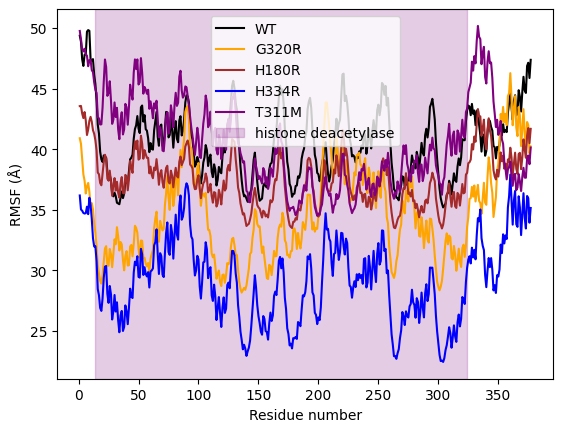

In [7]:
%matplotlib inline

# Plot de RMSF van het wildtype/de mutant
plt.plot(c_alphas_WT.resids,
         R_WT.results.rmsf,
         color = 'black',
         label = 'WT'
         )
plt.plot(c_alphas_G320R.resids,
         R_G320R.results.rmsf,
         color = 'orange',
         label = 'G320R'
         )
plt.plot(c_alphas_H180R.resids,
         R_H180R.results.rmsf,
         color = 'brown',
         label = 'H180R'
         )
plt.plot(c_alphas_H334R.resids,
         R_H334R.results.rmsf,
         color = 'blue',
         label = 'H334R'
         )
plt.plot(c_alphas_T311M.resids,
         R_T311M.results.rmsf,
         color = 'purple',
         label = 'T311M'
         )
plt.xlabel('Residue number')
plt.ylabel('RMSF (Å)')

plt.axvspan(14, 324, zorder=0, alpha=0.2, color='purple', label='histone deacetylase')


plt.legend()

Visibly, G320R and H334R have a lot lower RMSF than the wildtype.

### Secondary Structures


In [141]:
for variant in [WT_secondary, G320R_secondary, H180R_secondary, H334R_secondary, T311M_secondary]:
    long_run = DSSP(variant).run()
    mean_secondary_structure = translate(long_run.results.dssp_ndarray.mean(axis=0))
    print(''.join(mean_secondary_structure))

ValueError: Universe contains unequal numbers of (N,CA,C,O) atoms ('name' field). Please select appropriate AtomGroup manually.

### Distance Analysis

In [149]:
# Calculate dist from mutation to active site (Zn2+)
distances.distance_array

def dist_from_active_site(mutant, resid):
    zn = mutant.select_atoms("resid 378 and name ZN")
    site = mutant.select_atoms(resid)


    com1 = zn.center_of_mass()
    com2 = site.center_of_mass()
    dist = np.linalg.norm(com1-com2)

    return dist

mutant_dict = \
    { G320R_avg: ("G320R", "resid 320"),
      H180R_avg: ("H180R", "resid 180"),
      H334R_avg: ("H334R", "resid 334"),
      T311M_avg: ("T311M", "resid 311"),
      }

for mutant, (name, resid) in mutant_dict.items():
    dist = dist_from_active_site(mutant, resid)
    print(f"Distance from mutation {name} to active site: {round(dist, 2)}Å")


Distance from mutation G320R to active site: 22.59 Å
Distance from mutation H180R to active site: 5.8 Å
Distance from mutation H334R to active site: 30.7 Å
Distance from mutation T311M to active site: 10.5 Å


Mutation H180R seems to be the closest to the active site, with 5.8Å and H334R seems to be the mutation furthest away. A mutation closer to the active site could have a bigger impact on the catalytic activity.

Text(0, 0.5, 'Distance (Å)')

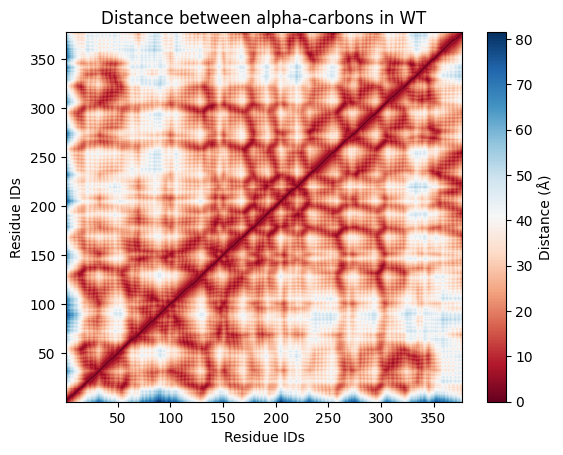

In [131]:
ca = WT.select_atoms('name CA')
n_ca = len(ca)

self_distances = distances.self_distance_array(ca.positions)
sq_dist_arr_WT = np.zeros((n_ca, n_ca))
triu = np.triu_indices_from(sq_dist_arr_WT, k=1)
sq_dist_arr_WT[triu] = self_distances
sq_dist_arr_WT.T[triu] = self_distances

fig, ax = plt.subplots()
im = ax.pcolor(ca.resids, ca.resids, sq_dist_arr_WT)

# add figure labels and titles
plt.ylabel('Residue IDs')
plt.xlabel('Residue IDs')
plt.title('Distance between alpha-carbons in WT')

# colorbar
cbar = fig.colorbar(im)
cbar.ax.set_ylabel('Distance (Å)')

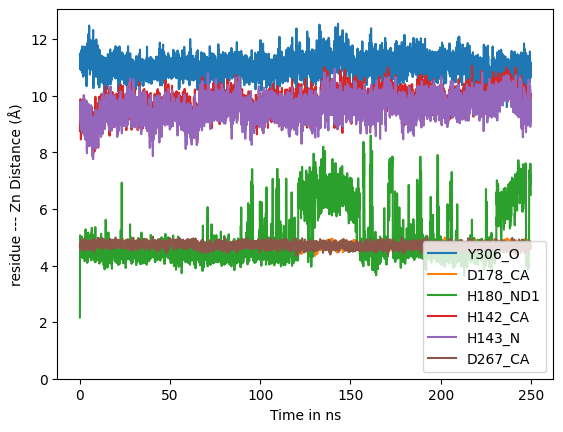

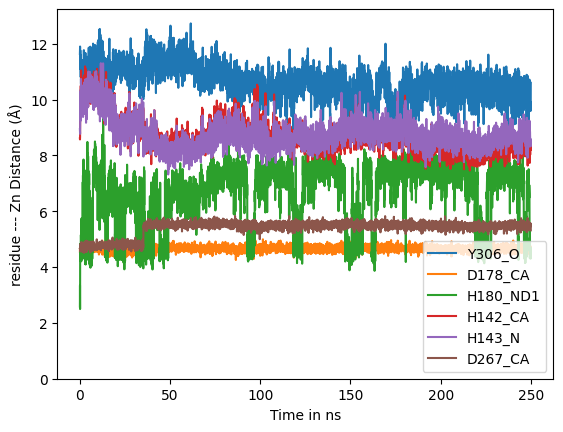

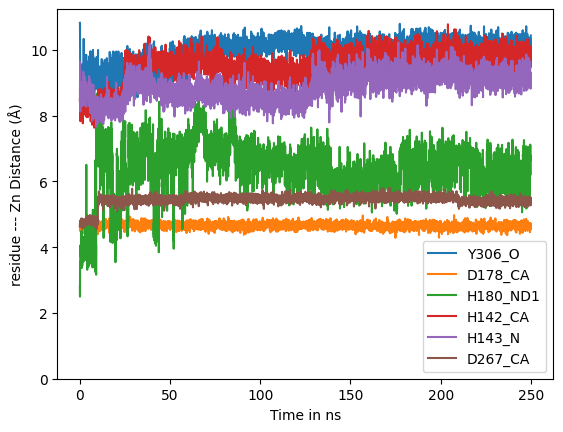

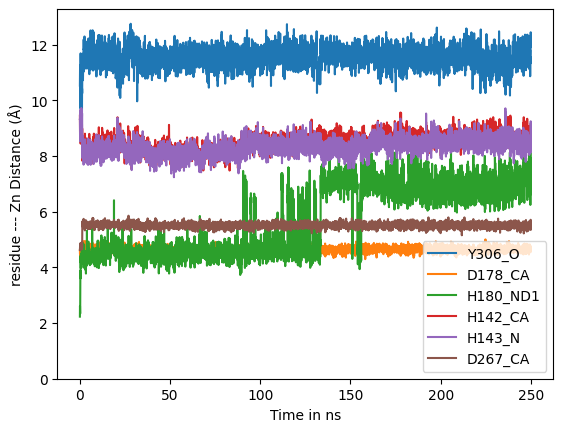

In [137]:
# Calculate dist between active site Zn2+ and vital residues for catalytic activity
def residue_zn_dist(variant):
    dL_variant_Y306 = calculate_dist(variant, "resid 306 and name O")
    dL_variant_D178 = calculate_dist(variant, "resid 178 and name CA")
    dL_variant_H180 = calculate_dist(variant, "resid 180 and name ND1")
    dL_variant_H142 = calculate_dist(variant, "resid 142 and name CA")
    dL_variant_H143 = calculate_dist(variant, "resid 143 and name N")
    dL_variant_D267 = calculate_dist(variant, "resid 267 and name CA")

    x = np.linspace(0, 250, len(dL_variant_Y306))

    plt.plot(x, dL_variant_Y306, label = "Y306_O")
    plt.plot(x, dL_variant_D178, label = "D178_CA")
    plt.plot(x, dL_variant_H180, label = "H180_ND1")
    plt.plot(x, dL_variant_H142, label = "H142_CA")
    plt.plot(x, dL_variant_H143, label = "H143_N")
    plt.plot(x, dL_variant_D267, label = "D267_CA")

    plt.ylabel("residue --- Zn Distance (Å)")
    plt.xlabel("Time in ns")
    plt.ylim(bottom=0)
    plt.legend()
    plt.show()

for variant in [WT, G320R, H334R, T311M]:
    residue_zn_dist(variant)

In [133]:
# Calculate dist between any resid and Zn2+ ion, based on center of mass
def calculate_dist(universe, resid):
  cofactor = universe.select_atoms("resid 378 and name ZN")
  residue = universe.select_atoms(resid)

  dL = []
  for _ in universe.trajectory:
    com1 = cofactor.center_of_mass()
    com2 = residue.center_of_mass()
    dL.append(np.linalg.norm(com1-com2))

  return dL

H180R has to be done seperately as there is no ND1

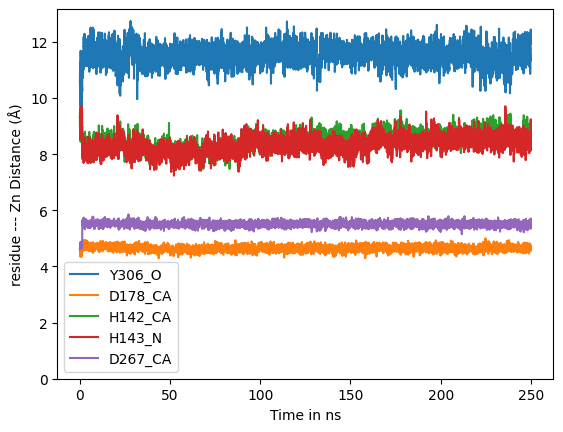

In [136]:
dL_H180R_Y306 = calculate_dist(variant, "resid 306 and name O")
dL_H180R_D178 = calculate_dist(variant, "resid 178 and name CA")
dL_H180R_H142 = calculate_dist(variant, "resid 142 and name CA")
dL_H180R_H143 = calculate_dist(variant, "resid 143 and name N")
dL_H180R_D267 = calculate_dist(variant, "resid 267 and name CA")

x = np.linspace(0, 250, len(dL_H180R_Y306))

plt.plot(x, dL_H180R_Y306, label = "Y306_O")
plt.plot(x, dL_H180R_D178, label = "D178_CA")
plt.plot(x, dL_H180R_H142, label = "H142_CA")
plt.plot(x, dL_H180R_H143, label = "H143_N")
plt.plot(x, dL_H180R_D267, label = "D267_CA")

plt.ylabel("residue --- Zn Distance (Å)")
plt.xlabel("Time in ns")
plt.ylim(bottom=0)
plt.legend()
plt.show()

https://userguide.mdanalysis.org/stable/examples/analysis/distances_and_contacts/distances_between_selections.html

The catalytic machinery lies at the end of the hydrophobic tunnel. The centerpiece of this region is a zinc ion that is bound to carboxylate oxygens of D178 and D267, and to the Nδ1 atom of H180

https://www.cell.com/structure/fulltext/S0969-2126(04)00159-5?_returnURL=https%3A%2F%2Flinkinghub.elsevier.com%2Fretrieve%2Fpii%2FS0969212604001595%3Fshowall%3Dtrue info over structuren

Text(0, 0.5, 'Distance (Å)')

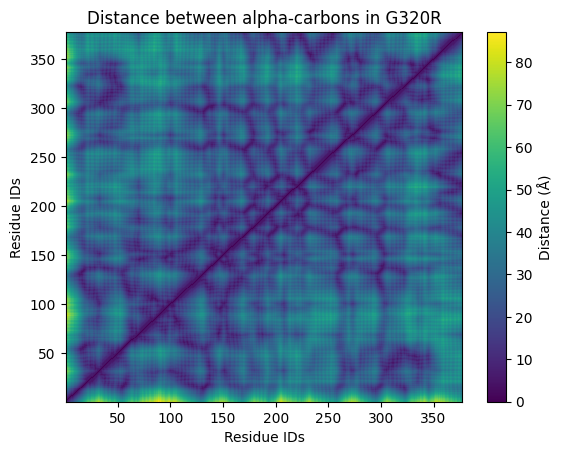

In [28]:
u = mda.Universe("../variants/G320R-1-ion.pdb")
ca = u.select_atoms('name CA')
n_ca = len(ca)

self_distances = distances.self_distance_array(ca.positions)
sq_dist_arr = np.zeros((n_ca, n_ca))
triu = np.triu_indices_from(sq_dist_arr, k=1)
sq_dist_arr[triu] = self_distances
sq_dist_arr.T[triu] = self_distances

fig, ax = plt.subplots()
im = ax.pcolor(ca.resids, ca.resids, sq_dist_arr)

# add figure labels and titles
plt.ylabel('Residue IDs')
plt.xlabel('Residue IDs')
plt.title('Distance between alpha-carbons in G320R')

# colorbar
cbar = fig.colorbar(im)
cbar.ax.set_ylabel('Distance (Å)')

Text(0, 0.5, 'Distance (Å)')

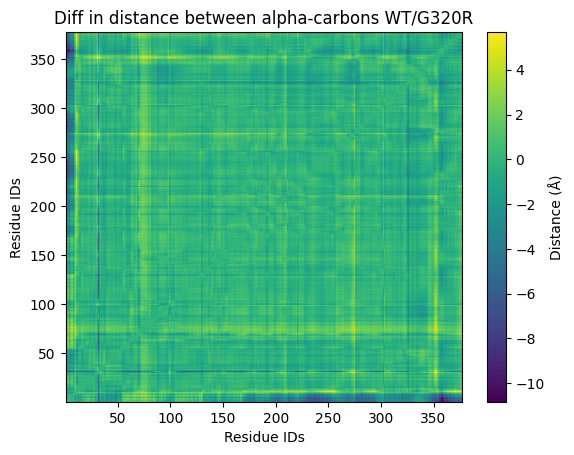

In [31]:
diff_distances_WT_G320R = np.subtract(sq_dist_arr_WT, sq_dist_arr)

fig, ax = plt.subplots()
im = ax.pcolor(ca.resids, ca.resids, diff_distances_WT_G320R)

# add figure labels and titles
plt.ylabel('Residue IDs')
plt.xlabel('Residue IDs')
plt.title('Diff in distance between alpha-carbons WT/G320R')

# colorbar
cbar = fig.colorbar(im)
cbar.ax.set_ylabel('Distance (Å)')

The simulations are 5000 frames of 0.5ns each (total 250ns). We want to only look at the final 50ns, as the protein will have folded out from crystallized structure. To do that we can use the code below. -b and -e are the start and endpoint measured in picoseconds.

```
gmx trjconv -f .xtc -o final_50ns.xtc -b 200000 -e 250000
```

Make subset version of tpr (no solvent) met echo 0
```
gmx convert-tpr -s ../../G320R-1/G320R-1-MD.tpr -n ../../index.ndx -o G320R-1-ion.tpr
```

Now the average configuration can be determined for each residue

```
gmx rmsf -f spliced.xtc -s G320R-1-ion.tpr -ox avg_structure.pdb
```



Text(0, 0.5, 'Distance (Å)')

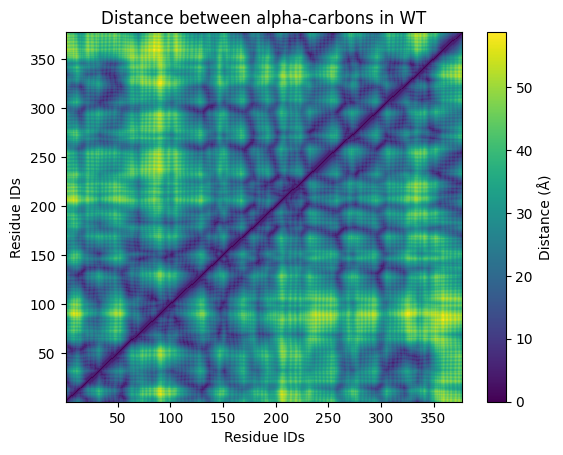

In [73]:
ca1 = WT_avg.select_atoms('name CA')
n_ca1 = len(ca1)

self_distances = distances.self_distance_array(ca.positions)
sq_dist_arr = np.zeros((n_ca1, n_ca1))
triu = np.triu_indices_from(sq_dist_arr, k=1)
sq_dist_arr[triu] = self_distances
sq_dist_arr.T[triu] = self_distances

fig, ax = plt.subplots()
im = ax.pcolor(ca1.resids, ca1.resids, sq_dist_arr)

# add figure labels and titles
plt.ylabel('Residue IDs')
plt.xlabel('Residue IDs')
plt.title('Distance between alpha-carbons in WT')

# colorbar
cbar = fig.colorbar(im)
cbar.ax.set_ylabel('Distance (Å)')


Text(0, 0.5, 'Distance (Å)')

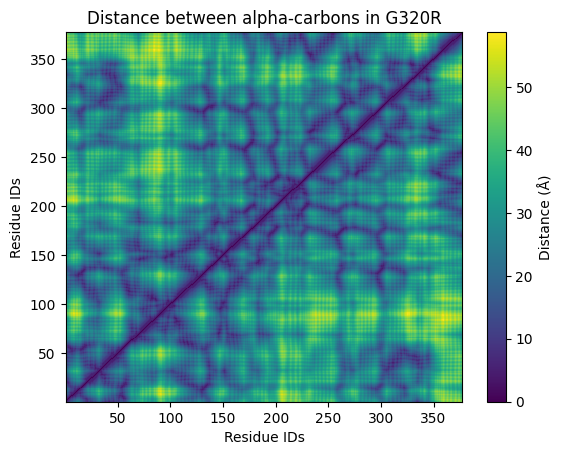

In [74]:
ca2 = G320R_avg.select_atoms('name CA')
n_ca2 = len(ca2)

self_distances = distances.self_distance_array(ca.positions)
sq_dist_arr = np.zeros((n_ca2, n_ca2))
triu = np.triu_indices_from(sq_dist_arr, k=1)
sq_dist_arr[triu] = self_distances
sq_dist_arr.T[triu] = self_distances

fig, ax = plt.subplots()
im = ax.pcolor(ca2.resids, ca2.resids, sq_dist_arr)

# add figure labels and titles
plt.ylabel('Residue IDs')
plt.xlabel('Residue IDs')
plt.title('Distance between alpha-carbons in G320R')

# colorbar
cbar = fig.colorbar(im)
cbar.ax.set_ylabel('Distance (Å)')

It difficult to determine the difference in distance between alpha carbons between WT and G320R, as alpha carbons are more stabile and thus will likely not be that affected by a mutation. For this reason we will look at the delta distance between alpha carbons between the two variants.

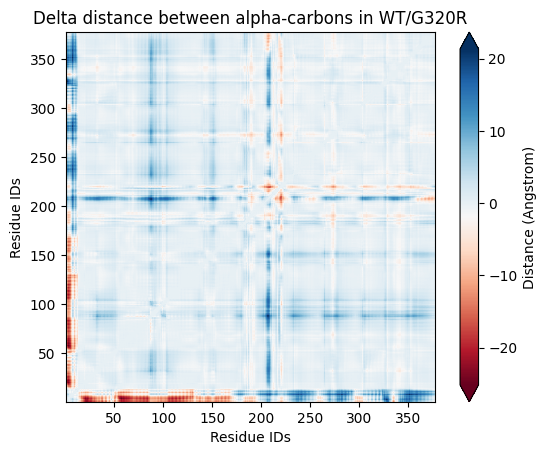

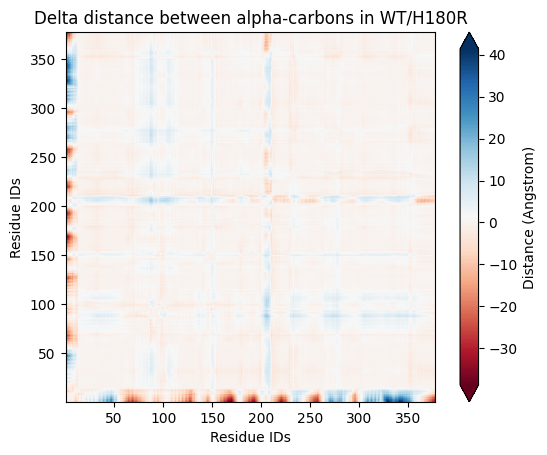

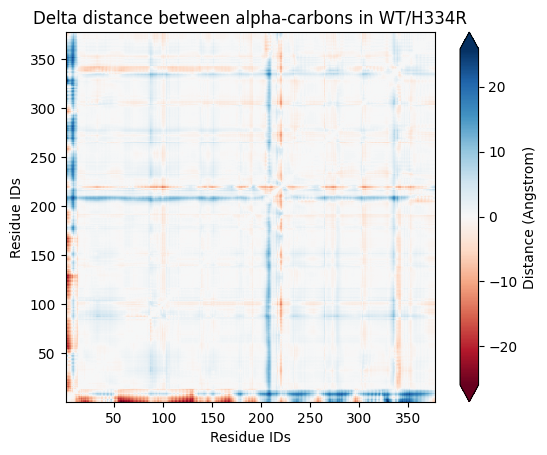

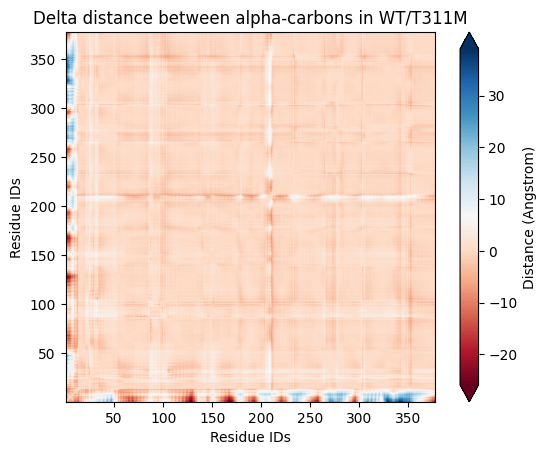

In [127]:
def delta_dist_WT_mutant(mutant, name):
    ca1 = WT_avg.select_atoms("name CA")
    ca2 = mutant.select_atoms("name CA")

    # pairwise distances
    distances_1 = distances.self_distance_array(ca1.positions)
    distances_2 = distances.self_distance_array(ca2.positions)

    N = len(ca1)
    M1 = np.zeros((N, N))
    M2 = np.zeros((N, N))

    triu = np.triu_indices(N, k=1)

    M1[triu] = distances_1
    M1.T[triu] = distances_1

    M2[triu] = distances_2
    M2.T[triu] = distances_2

    delta = M2 - M1  # Diff between coordinates of WT and mutant

    fig, ax = plt.subplots()
    im = ax.pcolor(ca.resids, ca.resids, delta)

    # plt.pcolor gives a rectangular grid by default
    # so we need to make our heatmap square
    ax.set_aspect('equal')

    # add figure labels and titles
    plt.ylabel('Residue IDs')
    plt.xlabel('Residue IDs')
    plt.title(f'Delta distance between alpha-carbons in WT/{name}')
    plt.set_cmap("RdBu")
    # colorbar
    cbar = fig.colorbar(im, extend='both')
    cbar.ax.set_ylabel('Distance (Angstrom)')
    plt.show()

mutant_dict = {G320R_avg:"G320R", H180R_avg:"H180R", H334R_avg:"H334R", T311M_avg:"T311M"}

for mutant in mutant_dict:
    delta_dist_WT_mutant(mutant, mutant_dict[mutant])


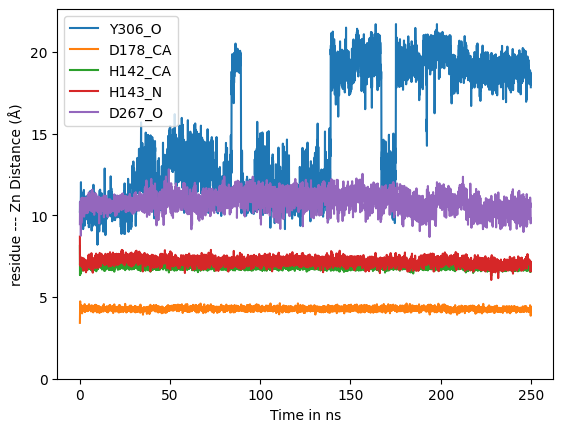

In [51]:
dL_H180R_Y306 = (calculate_dist("../variants/H180R-1-ion.pdb", "../variants/H180R-1-ion.xtc", "resid 306 and name OH"))
dL_H180R_D178 = (calculate_dist("../variants/H180R-1-ion.pdb", "../variants/H180R-1-ion.xtc", "resid 178 and name CA"))
# H180 is not included, as this mutant has mutated H180 -> R, so ND1 is no longer present
#dL_H180R_H180 = (calculate_dist("../variants/H180R-1-ion.pdb", "../variants/H180R-1-ion.xtc", "resid 180 and name ND1"))
dL_H180R_H142 = (calculate_dist("../variants/H180R-1-ion.pdb", "../variants/H180R-1-ion.xtc", "resid 142 and name CA"))
dL_H180R_H143 = (calculate_dist("../variants/H180R-1-ion.pdb", "../variants/H180R-1-ion.xtc", "resid 143 and name N"))
dL_H180R_D267 = (calculate_dist("../variants/H180R-1-ion.pdb", "../variants/H180R-1-ion.xtc", "resid 267 and name O"))

x = np.linspace(0, 250, len(dL_H180R_Y306))

plt.plot(x, dL_H180R_Y306, label = "Y306_O")
plt.plot(x, dL_H180R_D178, label = "D178_CA")
#plt.plot(x, dL_H180R_H180, label = "D180_ND1")
plt.plot(x, dL_H180R_H142, label = "H142_CA")
plt.plot(x, dL_H180R_H143, label = "H143_N")
plt.plot(x, dL_H180R_D267, label = "D267_O")

plt.ylabel("residue --- Zn Distance (Å)")
plt.xlabel("Time in ns")
plt.ylim(bottom=0)
plt.legend()
plt.show()

## PCA
Op lokaal gebied (binnenste 2 schillen vanaf zn/active site), maar ook van de beweging in het geheel


In [76]:
u = mda.Universe("../variants/WT-1-ion.pdb", "../variants/WT-1-ion.xtc")
PSF_pca = pca.PCA(u, select='backbone')
PSF_pca.run()

In [77]:
n_pcs = np.where(PSF_pca.results.cumulated_variance > 0.95)[0][0]
atomgroup = u.select_atoms('backbone')
pca_space = PSF_pca.transform(atomgroup, n_components=n_pcs)

In [78]:
pca_space

array([[-805.74691515, -159.12203747,  225.68467573,   86.52954167,
        -395.04699832,  -47.24109004],
       [-797.39778707, -154.60605153,  239.79925814,   80.40691866,
        -374.06539846,  -94.17758113],
       [-817.33830963, -144.09640507,  308.79917378,   94.45311605,
        -326.85431574, -122.78694335],
       ...,
       [-694.02710462, 1283.62576678,  -30.34824097, -420.01077418,
         439.96001763, -268.03732192],
       [-682.53302067, 1315.29504452,   -6.06046293, -420.17651869,
         430.00515054, -262.57371962],
       [ 938.9665014 , 1015.44931277, -149.91588749, -186.30957703,
         483.23435144, -244.48146974]], shape=(4706, 6))

# Sources
- Drazic, A., Myklebust, L. M., Ree, R., & Arnesen, T. (2016). The world of protein acetylation. Biochimica Et Biophysica Acta (BBA) - Proteins And Proteomics, 1864(10), 1372–1401. https://doi.org/10.1016/j.bbapap.2016.06.007
- De Ruijter, A. J., Van Gennip, A. H., Caron, H. N., Kemp, S., & Van Kuilenburg, A. B. (2003). Histone deacetylases (HDACs): characterization of the classical HDAC family. Biochemical Journal, 370(3), 737–749. https://doi.org/10.1042/bj20021321
- Deardorff, M. A., Bando, M., Nakato, R., Watrin, E., Itoh, T., Minamino, M., Saitoh, K., Komata, M., Katou, Y., Clark, D., Cole, K. E., De Baere, E., Decroos, C., Di Donato, N., Ernst, S., Francey, L. J., Gyftodimou, Y., Hirashima, K., Hullings, M., . . . Shirahige, K. (2012). HDAC8 mutations in Cornelia de Lange syndrome affect the cohesin acetylation cycle. Nature, 489(7415), 313–317. https://doi.org/10.1038/nature11316
- Bekker, Henk & Berendsen, Herman & Dijkstra, E.J. & Achterop, S. & Drunen, Rudi & van der Spoel, David & Sijbers, A. & Keegstra, H. & Reitsma, B. & Renardus, M.K.R.. (1993). Gromacs: A parallel computer for molecular dynamics simulations. Physics Computing. 92. 252-256.
- Brooks, B. R., Brooks, C. L., Mackerell, A. D., Nilsson, L., Petrella, R. J., Roux, B., Won, Y., Archontis, G., Bartels, C., Boresch, S., Caflisch, A., Caves, L., Cui, Q., Dinner, A. R., Feig, M., Fischer, S., Gao, J., Hodoscek, M., Im, W., . . . Karplus, M. (2009). CHARMM: The biomolecular simulation program. Journal Of Computational Chemistry, 30(10), 1545–1614. https://doi.org/10.1002/jcc.21287
- D.A. Case, H.M. Aktulga, K. Belfon, I.Y. Ben-Shalom, J.T. Berryman, S.R. Brozell, F.S. Carvahol, D.S. Cerutti, T.E. Cheatham, III, G.A. Cisneros, V.W.D. Cruzeiro, T.A. Darden, N. Forouzesh, M. Ghazimirsaeed, G. Giambaşu, T. Giese, M.K. Gilson, H. Gohlke, A.W. Goetz, J. Harris, Z. Huang, S. Izadi, S.A. Izmailov, K. Kasavajhala, M.C. Kaymak, I. Kolossv\'a ry, A. Kovalenko, T. Kurtzman, T.S. Lee, P. Li, Z. Li, C. Lin, J. Liu, T. Luchko, R. Luo, M. Machado, M. Manathunga, K.M. Merz, Y. Miao, O. Mikhailovskii, G. Monard, H. Nguyen, K.A. O'Hearn, A. Onufriev, F. Pan, S. Pantano, A. Rahnamoun, D.R. Roe, A. Roitberg, C. Sagui, S. Schott-Verdugo, A. Shajan, J. Shen, C.L. Simmerling, N.R. Skrynnikov, J. Smith, J. Swails, R.C. Walker, J. Wang, J. Wang, X. Wu, Y. Wu, Y. Xiong, Y. Xue, D.M. York, C. Zhao, Q. Zhu, and P.A. Kollman (2025), Amber 2025, University of California, San Francisco.
- De Lange, C. (1933). Surun type nouveau degeneration (typus Amestelodamensis). Arch Med Enfants, 36, 713-719.
- Kline, A. D., Moss, J. F., Selicorni, A., Bisgaard, A., Deardorff, M. A., Gillett, P. M., Ishman, S. L., Kerr, L. M., Levin, A. V., Mulder, P. A., Ramos, F. J., Wierzba, J., Ajmone, P. F., Axtell, D., Blagowidow, N., Cereda, A., Costantino, A., Cormier-Daire, V., FitzPatrick, D., . . . Hennekam, R. C. (2018). Diagnosis and management of Cornelia de Lange syndrome: first international consensus statement. Nature Reviews Genetics, 19(10), 649–666. https://doi.org/10.1038/s41576-018-0031-0
- Deardorff, M. A., Porter, N. J., & Christianson, D. W. (2016). Structural aspects of HDAC8 mechanism and dysfunction in Cornelia de Lange syndrome spectrum disorders. Protein Science, 25(11), 1965–1976. https://doi.org/10.1002/pro.3030
- Osko, J. D., Porter, N. J., Decroos, C., Lee, M. S., Watson, P. R., Raible, S. E., Krantz, I. D., Deardorff, M. A., & Christianson, D. W. (2020). Structural analysis of histone deacetylase 8 mutants associated with Cornelia de Lange Syndrome spectrum disorders. Journal Of Structural Biology, 213(1), 107681. https://doi.org/10.1016/j.jsb.2020.107681
- Decroos, C., Christianson, N. H., Gullett, L. E., Bowman, C. M., Christianson, K. E., Deardorff, M. A., & Christianson, D. W. (2015). Biochemical and Structural Characterization of HDAC8 Mutants Associated with Cornelia de Lange Syndrome Spectrum Disorders. Biochemistry, 54(42), 6501–6513. https://doi.org/10.1021/acs.biochem.5b00881